In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder,OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score,recall_score

In [3]:
df= pd.read_csv("loan_approval_data.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
df.describe

<bound method NDFrame.describe of      Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status  \
0             1.0           17795.0              1387.0          Salaried   
1             2.0            2860.0              2679.0          Salaried   
2             3.0            7390.0              2106.0          Salaried   
3             4.0           13964.0              8173.0          Salaried   
4             5.0           13284.0              4223.0     Self-employed   
..            ...               ...                 ...               ...   
995         996.0               NaN              9092.0          Salaried   
996         997.0            3279.0              6356.0     Self-employed   
997         998.0           15192.0              8433.0          Contract   
998         999.0            9083.0              7380.0        Unemployed   
999        1000.0           13093.0              2385.0          Salaried   

      Age Marital_Status  Dependents  Cre

In [5]:
#Handling missing value

categorical_col= df.select_dtypes(include=["object"]).columns
numerical_col=df.select_dtypes(include=["float64"]).columns
print(numerical_col)

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [6]:
num_imp=SimpleImputer(strategy="mean")
df[numerical_col]=num_imp.fit_transform(df[numerical_col])

cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_col]=cat_imp.fit_transform(df[categorical_col])

df.isnull().sum()



Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

0       No
1       No
2      Yes
3       No
4      Yes
      ... 
995     No
996     No
997     No
998    Yes
999     No
Name: Loan_Approved, Length: 1000, dtype: object


([<matplotlib.patches.Wedge at 0x1929ccd0910>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'No'),
  Text(0.6521428261765839, -0.8858384357581341, 'Yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

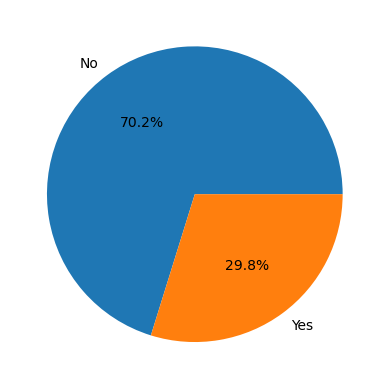

In [8]:
#EDA-Exploratory data Analysis
print(df["Loan_Approved"])
classes_count=df["Loan_Approved"].value_counts()

plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")


[Text(0, 0, '621'), Text(0, 0, '379')]

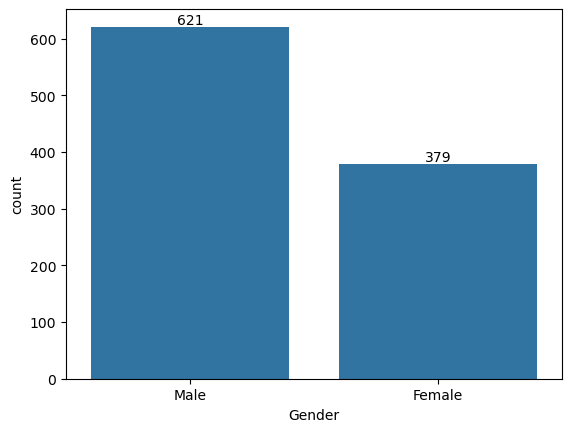

In [7]:
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

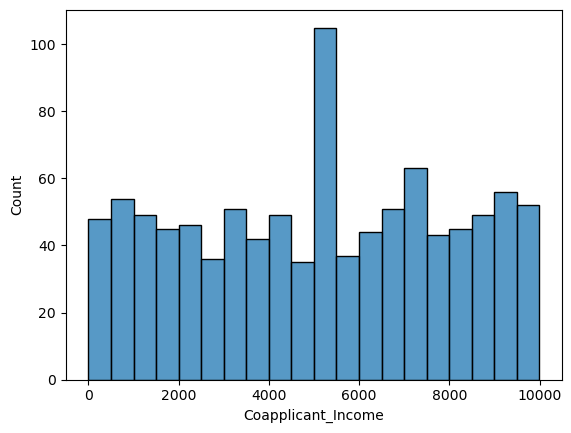

In [8]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

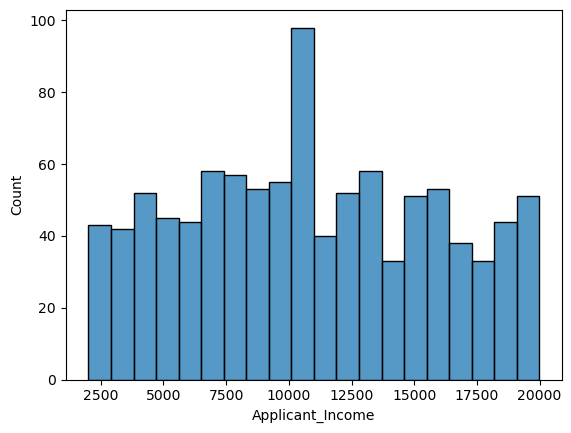

In [9]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

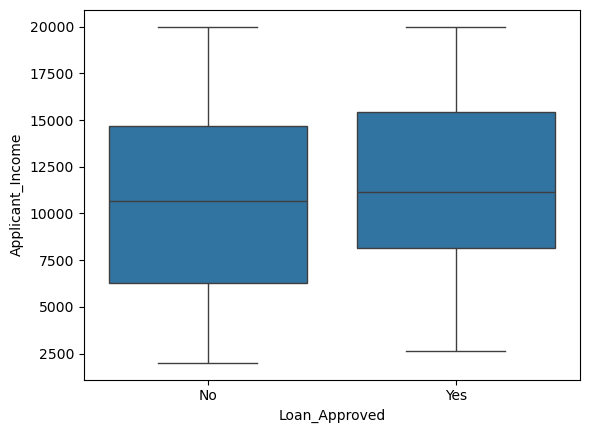

In [10]:
#outliers

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

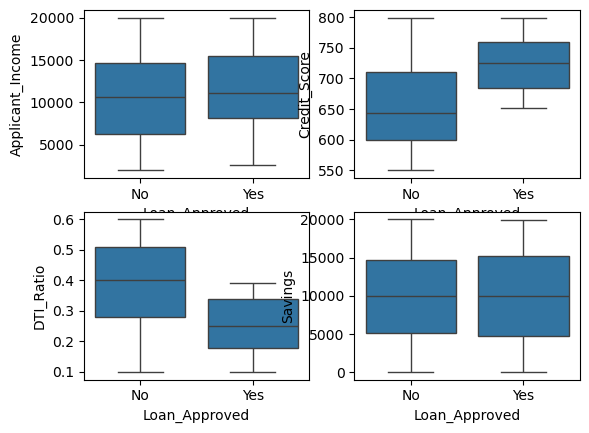

In [11]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")

plt.tight_layout

<Axes: xlabel='Credit_Score', ylabel='Count'>

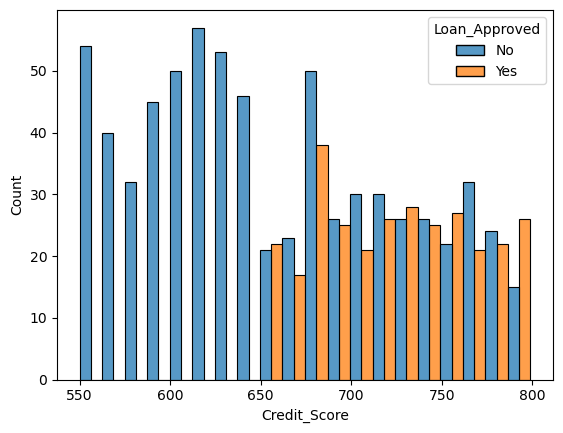

In [12]:
#credit score with loan amount
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

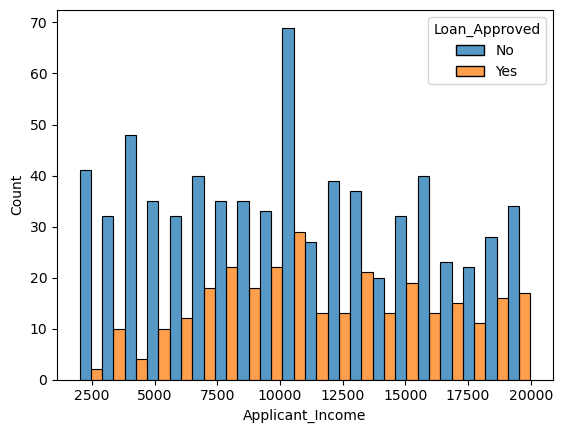

In [13]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [14]:
#Feature Encoding
#Label Encoding

le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,0
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,0
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,0
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,1


In [15]:
#OneHot Encoding

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
print(encoded)
encoded_df = pd.DataFrame(encoded, columns= ohe.get_feature_names_out(cols),index=df.index)
encoded_df

[[1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]]


,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [16]:
df=pd.concat([df.drop(columns=cols), encoded_df], axis=1)

print(df)


     Applicant_ID  Applicant_Income  Coapplicant_Income   Age  Dependents  \
0             1.0      17795.000000              1387.0  51.0         0.0   
1             2.0       2860.000000              2679.0  46.0         3.0   
2             3.0       7390.000000              2106.0  25.0         2.0   
3             4.0      13964.000000              8173.0  40.0         2.0   
4             5.0      13284.000000              4223.0  31.0         2.0   
..            ...               ...                 ...   ...         ...   
995         996.0      10852.571579              9092.0  58.0         0.0   
996         997.0       3279.000000              6356.0  58.0         1.0   
997         998.0      15192.000000              8433.0  48.0         1.0   
998         999.0       9083.000000              7380.0  50.0         1.0   
999        1000.0      13093.000000              2385.0  23.0         1.0   

     Credit_Score  Existing_Loans  DTI_Ratio       Savings  Collateral_Valu

In [17]:
df=df.drop(columns="Applicant_ID",axis=1)
print(df)

     Applicant_Income  Coapplicant_Income   Age  Dependents  Credit_Score  \
0        17795.000000              1387.0  51.0         0.0         637.0   
1         2860.000000              2679.0  46.0         3.0         621.0   
2         7390.000000              2106.0  25.0         2.0         674.0   
3        13964.000000              8173.0  40.0         2.0         579.0   
4        13284.000000              4223.0  31.0         2.0         721.0   
..                ...                 ...   ...         ...           ...   
995      10852.571579              9092.0  58.0         0.0         557.0   
996       3279.000000              6356.0  58.0         1.0         646.0   
997      15192.000000              8433.0  48.0         1.0         666.0   
998       9083.000000              7380.0  50.0         1.0         748.0   
999      13093.000000              2385.0  23.0         1.0         613.0   

     Existing_Loans  DTI_Ratio       Savings  Collateral_Value  Loan_Amount

<Axes: >

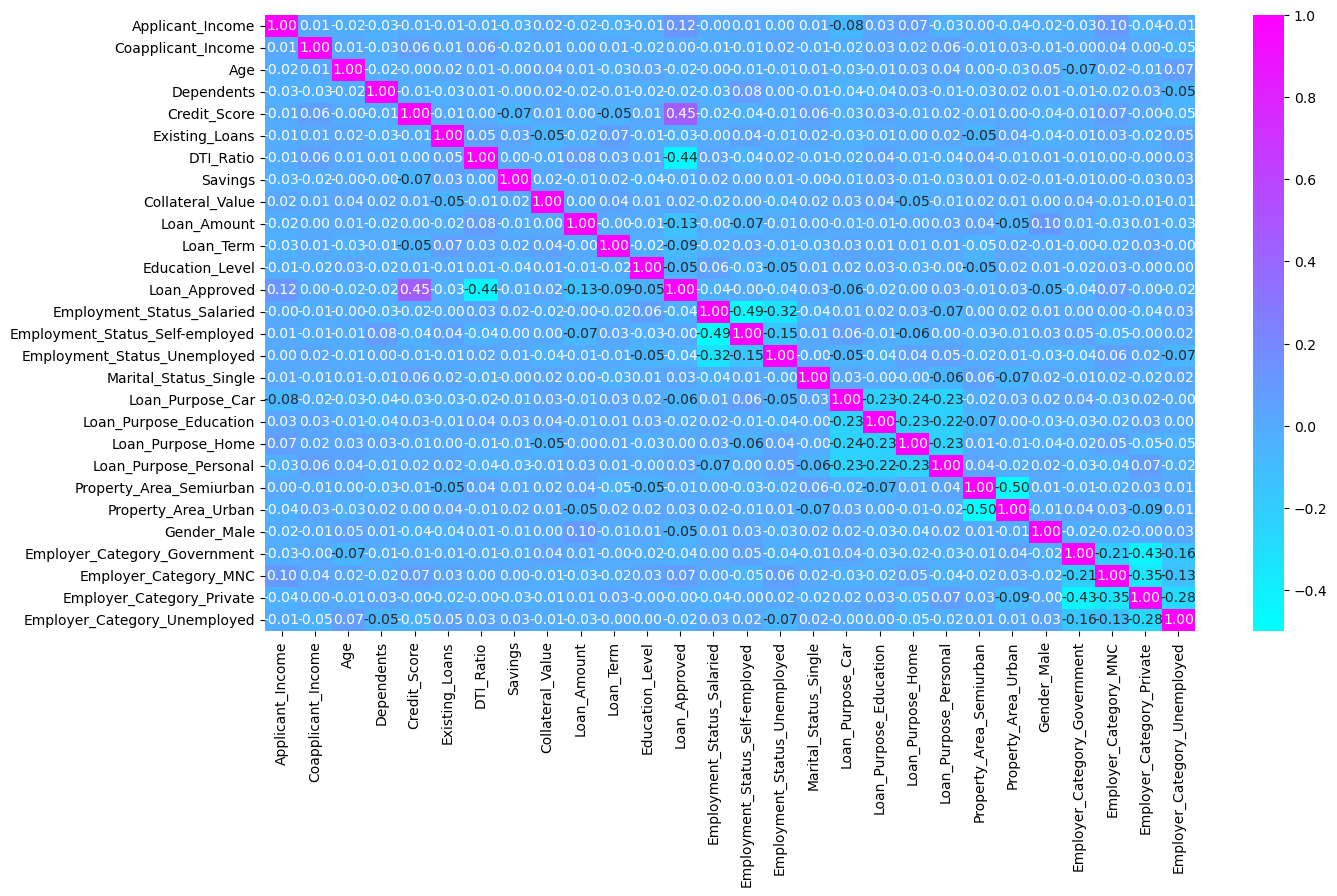

In [18]:
#corelation heatmap
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="cool"
)

In [19]:
#Train test and split , scaling 

X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]



In [20]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [21]:
scaler =StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [22]:
#Model training and evaluation

#Logistic Regression 
from sklearn.linear_model import LogisticRegression


logistic_model= LogisticRegression()
logistic_model.fit(X_train_scaled,y_train)

y_pred= logistic_model.predict(X_test_scaled)

print("Evalution metrix for logistic regression:")
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("Confusion metrix:", confusion_matrix(y_test,y_pred))

Evalution metrix for logistic regression:
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1: 0.7768595041322314
Confusion metrix: [[126  13]
 [ 14  47]]


In [23]:
#K-Nearest Neighbor
from sklearn.neighbors import KNeighborsClassifier


KNN_model= KNeighborsClassifier(n_neighbors=7)

KNN_model.fit(X_train_scaled,y_train)
y_pred= KNN_model.predict(X_test_scaled)

print("Evalution metrix for logistic regression:")
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("Confusion metrix:", confusion_matrix(y_test,y_pred))


Evalution metrix for logistic regression:
Precision: 0.6086956521739131
Recall: 0.45901639344262296
F1: 0.5233644859813084
Confusion metrix: [[121  18]
 [ 33  28]]


In [24]:
#Gaussion Navie Bayes 
from sklearn.naive_bayes import GaussianNB


NB_model=GaussianNB()

NB_model.fit(X_train_scaled,y_train)
y_pred= NB_model.predict(X_test_scaled)

print("Evalution metrix for logistic regression:")
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("Confusion metrix:", confusion_matrix(y_test,y_pred))

Evalution metrix for logistic regression:
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1: 0.7692307692307693
Confusion metrix: [[128  11]
 [ 16  45]]


In [25]:
#Feature Engineering 

df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

X=df.drop(columns=["DTI_Ratio","Credit_Score","Loan_Approved"])
y=df["Loan_Approved"]

print(X)
scaler =StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)



     Applicant_Income  Coapplicant_Income   Age  Dependents  Existing_Loans  \
0        17795.000000              1387.0  51.0         0.0             4.0   
1         2860.000000              2679.0  46.0         3.0             2.0   
2         7390.000000              2106.0  25.0         2.0             4.0   
3        13964.000000              8173.0  40.0         2.0             3.0   
4        13284.000000              4223.0  31.0         2.0             1.0   
..                ...                 ...   ...         ...             ...   
995      10852.571579              9092.0  58.0         0.0             0.0   
996       3279.000000              6356.0  58.0         1.0             3.0   
997      15192.000000              8433.0  48.0         1.0             1.0   
998       9083.000000              7380.0  50.0         1.0             3.0   
999      13093.000000              2385.0  23.0         1.0             3.0   

          Savings  Collateral_Value  Loan_Amount  L

In [26]:

#Logistic Regression 
from sklearn.linear_model import LogisticRegression


logistic_model= LogisticRegression()
logistic_model.fit(X_train_scaled,y_train)

y_pred= logistic_model.predict(X_test_scaled)

print("Evalution metrix for logistic regression:")
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("Confusion metrix:", confusion_matrix(y_test,y_pred))

Evalution metrix for logistic regression:
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1: 0.7768595041322314
Confusion metrix: [[126  13]
 [ 14  47]]


In [27]:
#K-Nearest Neighbor
from sklearn.neighbors import KNeighborsClassifier


KNN_model= KNeighborsClassifier(n_neighbors=7)

KNN_model.fit(X_train_scaled,y_train)
y_pred= KNN_model.predict(X_test_scaled)

print("Evalution metrix for logistic regression:")
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("Confusion metrix:", confusion_matrix(y_test,y_pred))

Evalution metrix for logistic regression:
Precision: 0.6086956521739131
Recall: 0.45901639344262296
F1: 0.5233644859813084
Confusion metrix: [[121  18]
 [ 33  28]]


In [28]:
#Gaussion Navie Bayes 
from sklearn.naive_bayes import GaussianNB


NB_model=GaussianNB()

NB_model.fit(X_train_scaled,y_train)
y_pred= NB_model.predict(X_test_scaled)

print("Evalution metrix for logistic regression:")
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("Confusion metrix:", confusion_matrix(y_test,y_pred))

Evalution metrix for logistic regression:
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1: 0.7692307692307693
Confusion metrix: [[128  11]
 [ 16  45]]
